# RF for airfoil performance prediction based on CST-LHS sampled data

In [3]:
import pandas as pd
import numpy as np
dataset = pd.read_csv("D:/Airfoil_Surrogate_Modelling/Dataset.csv")

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


X = dataset.drop(['CL', 'CD', 'Airfoil'], axis=1)
y_cl = dataset['CL']
y_cd = dataset['CD']

# Create the groups (airfoil names)
groups = dataset['Airfoil']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# This splits by AIRFOIL, not by rows!
train_idx, test_idx = next(gss.split(X, y_cl, groups=groups))

# Now use these indices to split your data
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_cl_train = y_cl.iloc[train_idx]
y_cl_test = y_cl.iloc[test_idx]
y_cd_train = y_cd.iloc[train_idx]
y_cd_test = y_cd.iloc[test_idx]

# Verify no airfoil appears in both sets
train_airfoils = set(dataset.iloc[train_idx]['Airfoil'])
test_airfoils = set(dataset.iloc[test_idx]['Airfoil'])
overlap = train_airfoils.intersection(test_airfoils)
print(f"Overlapping airfoils: {overlap}")  # Should be empty!
print(f"Train airfoils: {len(train_airfoils)}")
print(f"Test airfoils: {len(test_airfoils)}")

Overlapping airfoils: set()
Train airfoils: 260
Test airfoils: 65


In [5]:
# Train CL model
rf_cl = RandomForestRegressor(n_estimators=100, random_state=42)
rf_cl.fit(X_train, y_cl_train)

# Train CD model
rf_cd = RandomForestRegressor(n_estimators=100, random_state=42)
rf_cd.fit(X_train, y_cd_train)

# Predict and evaluate
y_cl_pred = rf_cl.predict(X_test)
y_cd_pred = rf_cd.predict(X_test)

# Calculate metrics
r2_cl = r2_score(y_cl_test, y_cl_pred)
rmse_cl = np.sqrt(mean_squared_error(y_cl_test, y_cl_pred))

r2_cd = r2_score(y_cd_test, y_cd_pred)
rmse_cd = np.sqrt(mean_squared_error(y_cd_test, y_cd_pred))

print("=== CL (Lift Coefficient) ===")
print(f"R²: {r2_cl:.4f}")
print(f"RMSE: {rmse_cl:.6f}")

print("\n=== CD (Drag Coefficient) ===")
print(f"R²: {r2_cd:.4f}")
print(f"RMSE: {rmse_cd:.6f}")

=== CL (Lift Coefficient) ===
R²: 0.9977
RMSE: 0.020129

=== CD (Drag Coefficient) ===
R²: 0.9927
RMSE: 0.000352


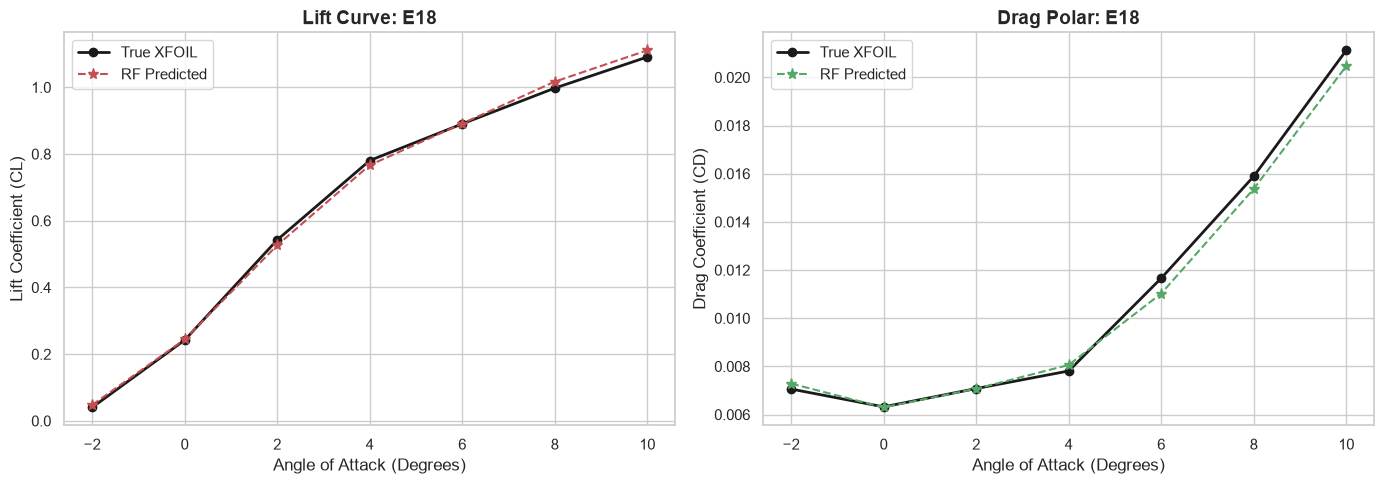

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Rebuild a Results DataFrame for easy plotting
# We use test_idx to grab the correct Airfoil names that were dropped from X_test
results_df = X_test.copy()
results_df['Airfoil'] = dataset.iloc[test_idx]['Airfoil']
results_df['CL_Actual'] = y_cl_test
results_df['CL_Predicted'] = y_cl_pred
results_df['CD_Actual'] = y_cd_test
results_df['CD_Predicted'] = y_cd_pred

# 2. Pick a single random airfoil from the test set to visualize
# You can change the [0] to [1], [2], etc., to look at different airfoils
sample_airfoil = results_df['Airfoil'].unique()[42]

# Filter the data for only this airfoil and sort it by Alpha so the line draws correctly
plot_data = results_df[results_df['Airfoil'] == sample_airfoil].sort_values(by='Alpha')

# 3. Create the plots (Side-by-side Lift and Drag)
sns.set_theme(style="whitegrid") # Makes the plots look modern and clean
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- LIFT CURVE (CL vs Alpha) ---
# Plot True values as a thick black solid line
ax1.plot(plot_data['Alpha'], plot_data['CL_Actual'], 'ko-', label='True XFOIL', linewidth=2)
# Plot ML Predicted values as red dashed lines with star markers
ax1.plot(plot_data['Alpha'], plot_data['CL_Predicted'], 'r*--', label='RF Predicted', markersize=8)

ax1.set_xlabel('Angle of Attack (Degrees)', fontsize=12)
ax1.set_ylabel('Lift Coefficient (CL)', fontsize=12)
ax1.set_title(f'Lift Curve: {sample_airfoil}', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)

# --- DRAG CURVE (CD vs Alpha) ---
# Plot True values as a thick black solid line
ax2.plot(plot_data['Alpha'], plot_data['CD_Actual'], 'ko-', label='True XFOIL', linewidth=2)
# Plot ML Predicted values as blue dashed lines with star markers
ax2.plot(plot_data['Alpha'], plot_data['CD_Predicted'], 'g*--', label='RF Predicted', markersize=8)

ax2.set_xlabel('Angle of Attack (Degrees)', fontsize=12)
ax2.set_ylabel('Drag Coefficient (CD)', fontsize=12)
ax2.set_title(f'Drag Polar: {sample_airfoil}', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

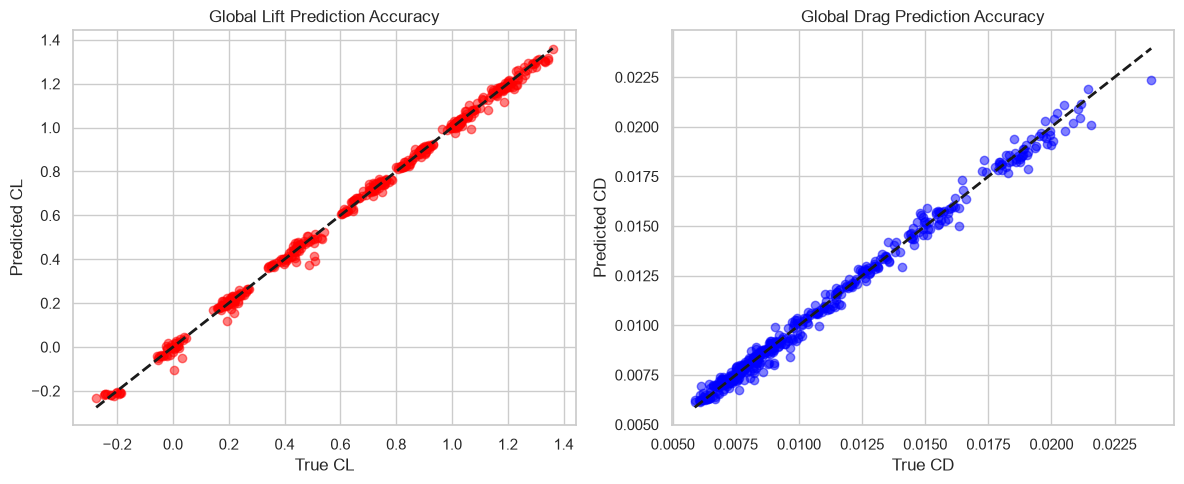

In [6]:
# --- GLOBAL PARITY PLOTS (All Test Data) ---
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 5))

# CL Parity Plot
ax3.scatter(results_df['CL_Actual'], results_df['CL_Predicted'], alpha=0.5, color='red')
ax3.plot([results_df['CL_Actual'].min(), results_df['CL_Actual'].max()],
         [results_df['CL_Actual'].min(), results_df['CL_Actual'].max()], 'k--', lw=2) # 45-degree line
ax3.set_xlabel('True CL')
ax3.set_ylabel('Predicted CL')
ax3.set_title('Global Lift Prediction Accuracy')

# CD Parity Plot
ax4.scatter(results_df['CD_Actual'], results_df['CD_Predicted'], alpha=0.5, color='blue')
ax4.plot([results_df['CD_Actual'].min(), results_df['CD_Actual'].max()],
         [results_df['CD_Actual'].min(), results_df['CD_Actual'].max()], 'k--', lw=2) # 45-degree line
ax4.set_xlabel('True CD')
ax4.set_ylabel('Predicted CD')
ax4.set_title('Global Drag Prediction Accuracy')

plt.tight_layout()
plt.show()

In [7]:
import joblib
joblib.dump(rf_cl, 'rf_cl.pkl')             # RF for CL
joblib.dump(rf_cd, 'rf_cd.pkl')             # RF for CL

['rf_cd.pkl']

In [6]:
# Get the list of test airfoils
test_airfoils_list = list(test_airfoils)
print("Test airfoils:", test_airfoils_list)
print(f"Total test airfoils: {len(test_airfoils_list)}")

Test airfoils: ['E13', 'G5', 'G50', 'B18', 'D51', 'B64', 'D53', 'D55', 'G29', 'B55', 'A13', 'E46', 'E32', 'D19', 'A19', 'A62', 'B26', 'D44', 'B21', 'G48', 'A17', 'A65', 'D25', 'B22', 'D40', 'A8', 'D5', 'A15', 'A33', 'E59', 'G7', 'E34', 'B28', 'A51', 'G37', 'B59', 'A40', 'G56', 'B51', 'E51', 'B6', 'B20', 'E53', 'B36', 'D52', 'E44', 'B37', 'D57', 'G55', 'G62', 'A49', 'A60', 'E22', 'E65', 'A52', 'E18', 'G33', 'A25', 'G20', 'G65', 'B33', 'B43', 'G35', 'D23', 'D31']
Total test airfoils: 65
